<a href="https://colab.research.google.com/github/yashvirchandra/assignment-01-2511924/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
!pip install sentence-transformers
!pip install matplotlib seaborn scikit-learn

In [49]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [50]:
sentences = [
    # Cricket :-
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the player.",
    "The team celebrated after winning the cricket tournament.",

    # Cooking :-
    "She added spices to the soup to enhance the flavor.",
    "The chef baked a delicious chocolate cake in the oven.",
    "Cooking pasta requires boiling water and adding salt.",

    # Cybersecurity :-
    "Strong passwords help protect accounts from hackers.",
    "Cybersecurity involves protecting systems from digital attacks.",
    "Encryption is used to secure sensitive data online.",
    "Firewalls are important tools for preventing unauthorized access."
]

In [51]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [52]:
embeddings = model.encode(sentences)

In [53]:
similarity_matrix = cosine_similarity(embeddings)

In [54]:
print(similarity_matrix)

[[ 1.0000002   0.37509236  0.5473509  -0.02366363  0.0889483  -0.09723365
  -0.02471411  0.00835818 -0.00552029 -0.0356597 ]
 [ 0.37509236  1.0000004   0.31107885  0.06831281  0.09028806  0.02060132
  -0.0399799  -0.02008114 -0.04109473  0.00766662]
 [ 0.5473509   0.31107885  1.          0.07679705  0.10167038 -0.04352239
  -0.0280393  -0.08372781 -0.02630767 -0.04350674]
 [-0.02366363  0.06831281  0.07679705  0.9999998   0.13361031  0.2977876
   0.03638922 -0.0367334   0.02481643 -0.00467446]
 [ 0.0889483   0.09028806  0.10167038  0.13361031  1.0000002   0.14043218
  -0.06448452  0.01157078  0.02876566 -0.01165761]
 [-0.09723365  0.02060132 -0.04352239  0.2977876   0.14043218  1.
   0.08968518 -0.04493231  0.06543356  0.11340929]
 [-0.02471411 -0.0399799  -0.0280393   0.03638922 -0.06448452  0.08968518
   1.0000001   0.34305346  0.36395514  0.433999  ]
 [ 0.00835818 -0.02008114 -0.08372781 -0.0367334   0.01157078 -0.04493231
   0.34305346  1.          0.48622003  0.44282985]
 [-0.0055

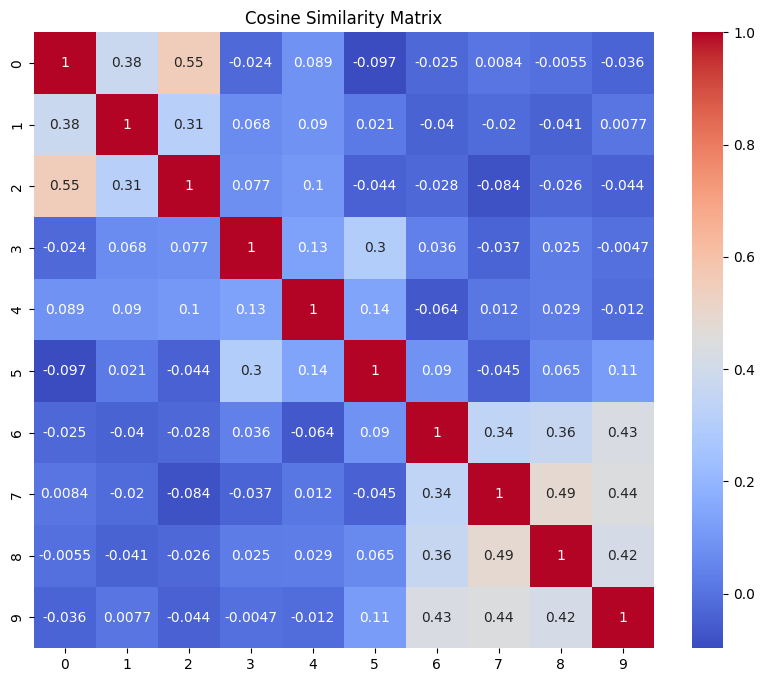

In [55]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [56]:
query = "The bowler took three wickets in one over"

In [57]:
query_embedding = model.encode([query])

In [58]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [59]:
top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", similarities[idx])
    print("------")

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679121
------
Sentence: The bowler delivered a fast yorker to dismiss the player.
Similarity Score: 0.5102545
------
